# ECCO-DarwinDiff — ML vs Green's-Functions Head-to-Head (Track 1 v0.5)

The question this notebook answers: **does the ML in "DarwinDiff" actually beat the structural class of Green's-functions calibration on the Carroll-2020 six-parameter target, on the same observation budget?**

Notebook 05 showed that autograd recovers six global scalars matching Carroll's Green's-functions optimum within single-digit %. But **autograd-fitted global scalars and Green's-functions-fitted global scalars are the same parametric class** — they differ in *how* they search the parameter space, not in *what* they can represent. Beating the search procedure does not yet beat the parameter class. To demonstrate that DarwinDiff outcompetes ECCO-Darwin in a way that matters scientifically, the setup needs to be one where global scalars *structurally cannot* match the truth, but per-region (or per-cell) ML predictions can.

**The setup.** Two synthetic regimes — Mid-Atlantic and Pacific — with **different true Carroll-6 values** reflecting plausible biogeochemistry contrasts (Mid-Atl: high Saharan dust → high `alpfe`, iron-replete growth; Pacific: low dust → low `alpfe`, iron-limited, more scavenging). Both observed jointly. Two contestants:

1. **Global-scalar fit (the ECCO-Darwin / Green's-functions parametric class).** Six global Carroll-6 scalars fit by autograd against the joint observation set. This is the *best possible* result for any approach restricted to one global scalar per parameter — at least as good as Green's-functions can do on the same data, since autograd gives the LSE solution exactly. The structural ceiling is approximately the regional mean of the truth.
2. **DarwinDiff + MLP.** A small MLP takes per-regime environmental covariates (SST, dust flux, MLD) and predicts the six Carroll-6 parameters *per regime*. Same autograd machinery, same observation set, single training run. The MLP weights have to find one mapping `(env) → params` that simultaneously fits both regimes.

The ML approach should clearly win on **per-regime recovery accuracy** because it can represent regional heterogeneity by construction. That is the structural argument behind the ORCD B200 burn-in pitch — and this notebook is the cleanest synthetic demonstration of it on the canonical Carroll-2020 six.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__}")
print(
    f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}"
)

PyTorch 2.11.0+cu128
Device: NVIDIA GeForce RTX 5090 Laptop GPU


## 1. Carroll-6 box model (recap from notebook 05)

Same 0-D Fe–phyto–POC–PIC box model as notebook 05. The box is unchanged; what differs between regimes is the truth parameter values and the environmental covariates the MLP sees. See notebook 05 for equation derivation and Carroll → Darwin 1 source mapping.

In [2]:
# Background (non-learned) parameters — the ~94% of Darwin knobs Carroll left at defaults.
M_LIN = 0.05
M_QUAD = 0.50
G0_GRAZE = 0.30
W_SINK = 0.10
K_FE = 5.0e-5
PHI_DUST = 5.0e-5
Q_FE = 1.0e-5
LIGHT = 1.0


def carroll6_step(state, params, dt):
    DFe, Ps, Pl, POC, PIC = state[0], state[1], state[2], state[3], state[4]
    alpfe, scav_rat, mu_s, mu_l, g_diatom, R_PICPOC = (
        params[0], params[1], params[2], params[3], params[4], params[5]
    )
    scav_rat_per_day = scav_rat * 86400.0
    f_fe = DFe / (DFe + K_FE)
    growth_s = mu_s * f_fe * LIGHT * Ps
    growth_l = mu_l * f_fe * LIGHT * Pl
    fe_uptake = Q_FE * (growth_s + growth_l)
    mort_s = M_LIN * Ps + M_QUAD * Ps * Ps
    mort_l = M_LIN * Pl + M_QUAD * Pl * Pl
    graze_l = g_diatom * G0_GRAZE * Pl
    mort_total = mort_s + mort_l + graze_l

    dDFe = alpfe * PHI_DUST - scav_rat_per_day * DFe * POC - fe_uptake
    dPs = growth_s - mort_s
    dPl = growth_l - mort_l - graze_l
    dPOC = mort_total - W_SINK * POC
    dPIC = R_PICPOC * mort_total - W_SINK * PIC

    return torch.stack([
        DFe + dt * dDFe,
        Ps + dt * dPs,
        Pl + dt * dPl,
        POC + dt * dPOC,
        PIC + dt * dPIC,
    ])


def carroll6_integrate(state0, params, dt, n_steps, snapshot_indices):
    state = state0
    snapshot_set = set(snapshot_indices)
    snaps = []
    for step in range(1, n_steps + 1):
        state = carroll6_step(state, params, dt)
        if step in snapshot_set:
            snaps.append(state)
    return torch.stack(snaps)


PARAM_NAMES = ["alpfe", "scav_rat", "Smallgrow", "Biggrow", "diatomgraz", "R_PICPOC"]
PARAM_BOUNDS = torch.tensor([
    [0.05, 1.0],
    [3e-8, 3e-6],
    [0.10, 2.0],
    [0.10, 2.0],
    [0.05, 1.0],
    [0.005, 0.20],
])


def bounded_params(theta, bounds):
    lo, hi = bounds[:, 0], bounds[:, 1]
    return lo + (hi - lo) * torch.sigmoid(theta)

## 2. Two regimes: Mid-Atlantic and Pacific

Each regime has:
- **Environmental covariates** (SST, dust flux, MLD) that the MLP gets to see.
- **True Carroll-6 parameter values** that the box model uses to generate observations. The truth differs between regimes in a biogeochemistry-plausible way.

**Mid-Atlantic (high-dust, productive):**
- High dust flux from Saharan transport → elevated `alpfe` (more soluble iron source).
- Lower iron scavenging due to abundant ligand-binding sites in well-mixed water.
- High small/large phyto growth (iron-replete).

**Pacific (subtropical gyre, low-dust):**
- Low dust flux → reduced `alpfe`.
- Higher scavenging of dissolved iron.
- Iron-limited phytoplankton → lower growth rates.
- Lower `R_PICPOC` (different cocco vs diatom community).

The truth values for each regime are within ±25 % of the Carroll 2020 global optimum — modest but meaningful regional contrast. Both observation sets feed the joint training data; both contestants see the same observations.

In [3]:
# Carroll 2020 global optimum from the JAMES paper, for reference only.
CARROLL_VALUES = torch.tensor([
    0.92831,
    10.41124 * 0.005 / 86400.0,
    0.66098,
    0.43148,
    0.83003,
    0.04245,
])

# Mid-Atlantic regime: high-dust, iron-replete, productive.
midatl_truth = torch.tensor([
    0.95,    # alpfe (high, dust-rich)
    4.0e-7,  # scav_rat (low scavenging)
    0.72,    # Smallgrow (high)
    0.50,    # Biggrow (high)
    0.85,    # diatomgraz
    0.048,   # R_PICPOC
])
midatl_env = torch.tensor([15.0, 1.0, 50.0])  # SST (degC), dust flux (norm), MLD (m)

# Pacific regime: subtropical gyre, low-dust, iron-limited.
pacific_truth = torch.tensor([
    0.62,    # alpfe (low)
    8.5e-7,  # scav_rat (high)
    0.52,    # Smallgrow (low)
    0.32,    # Biggrow (low)
    0.70,    # diatomgraz
    0.035,   # R_PICPOC
])
pacific_env = torch.tensor([25.0, 0.2, 80.0])

# Same physical setup as notebook 05.
state0 = torch.tensor([5.0e-4, 1.0, 1.0, 0.5, 0.025])
dt = 0.25
n_steps = 200
snapshot_indices = [40, 80, 120, 160, 200]

torch.manual_seed(42)
with torch.no_grad():
    midatl_truth_traj = carroll6_integrate(
        state0=state0, params=midatl_truth, dt=dt,
        n_steps=n_steps, snapshot_indices=snapshot_indices,
    )
    pacific_truth_traj = carroll6_integrate(
        state0=state0, params=pacific_truth, dt=dt,
        n_steps=n_steps, snapshot_indices=snapshot_indices,
    )

noise_level = 0.01
midatl_norm = midatl_truth_traj.mean(dim=0).clamp(min=1e-12)
pacific_norm = pacific_truth_traj.mean(dim=0).clamp(min=1e-12)
midatl_obs = (
    midatl_truth_traj + noise_level * midatl_norm * torch.randn_like(midatl_truth_traj)
)
pacific_obs = (
    pacific_truth_traj + noise_level * pacific_norm * torch.randn_like(pacific_truth_traj)
)

tracer_names = ["DFe", "Ps", "Pl", "POC", "PIC"]
print("Mid-Atlantic regime:")
print(f"  Env covariates (SST degC, dust norm, MLD m): {midatl_env.tolist()}")
print(f"  Final state at 50 d: {[f'{v.item():.3e}' for v in midatl_truth_traj[-1]]}")
print()
print("Pacific regime:")
print(f"  Env covariates (SST degC, dust norm, MLD m): {pacific_env.tolist()}")
print(f"  Final state at 50 d: {[f'{v.item():.3e}' for v in pacific_truth_traj[-1]]}")
print()
print("Per-regime truth deviation from Carroll-2020 global optimum:")
for i, name in enumerate(PARAM_NAMES):
    midatl_dev = abs(midatl_truth[i].item() - CARROLL_VALUES[i].item()) / CARROLL_VALUES[i].item() * 100
    pacific_dev = abs(pacific_truth[i].item() - CARROLL_VALUES[i].item()) / CARROLL_VALUES[i].item() * 100
    print(f"  {name:<11s}  Mid-Atl {midatl_dev:>5.1f}%  Pacific {pacific_dev:>5.1f}%")

Mid-Atlantic regime:
  Env covariates (SST degC, dust norm, MLD m): [15.0, 1.0, 50.0]
  Final state at 50 d: ['1.819e-04', '1.029e+00', '1.750e-01', '6.507e+00', '3.123e-01']

Pacific regime:
  Env covariates (SST degC, dust norm, MLD m): [25.0, 0.20000000298023224, 80.0]
  Final state at 50 d: ['1.453e-04', '6.731e-01', '1.873e-02', '2.651e+00', '9.284e-02']

Per-regime truth deviation from Carroll-2020 global optimum:
  alpfe        Mid-Atl   2.3%  Pacific  33.2%
  scav_rat     Mid-Atl  33.6%  Pacific  41.1%
  Smallgrow    Mid-Atl   8.9%  Pacific  21.3%
  Biggrow      Mid-Atl  15.9%  Pacific  25.8%
  diatomgraz   Mid-Atl   2.4%  Pacific  15.7%
  R_PICPOC     Mid-Atl  13.1%  Pacific  17.6%


## 3. Contestant 1: Global-scalar fit (Green's-functions parametric class)

The structural ceiling for any approach restricted to *one global Carroll-6 scalar set for the whole ocean*. Carroll 2020's Green's-functions workflow produces this class of solution. The autograd machinery here finds the *best possible* global scalar set on the joint Mid-Atl + Pacific observation set — a fair-or-better stand-in for what Green's-functions can do on the same data.

Best-case behaviour: the global scalars converge near the **average of the two regimes' truth values**, the LSE solution for jointly fitting two distinct truths with one parameter set.

In [4]:
# Force CPU for the same dispatch-overhead reasons as notebook 05.
fit_device = "cpu"
print(f"Fit device: {fit_device}")

bounds_dev = PARAM_BOUNDS.to(fit_device)
state0_dev = state0.to(fit_device)
midatl_obs_dev = midatl_obs.to(fit_device)
pacific_obs_dev = pacific_obs.to(fit_device)
midatl_norm_dev = midatl_norm.to(fit_device)
pacific_norm_dev = pacific_norm.to(fit_device)

n_epochs = 2000

torch.manual_seed(0)
theta_global = torch.zeros(6, requires_grad=True, device=fit_device)
optimizer_global = torch.optim.Adam([theta_global], lr=5e-2)
losses_global = []

t0 = time.time()
for epoch in range(n_epochs):
    optimizer_global.zero_grad()
    params = bounded_params(theta_global, bounds_dev)
    midatl_pred = carroll6_integrate(
        state0=state0_dev, params=params, dt=dt,
        n_steps=n_steps, snapshot_indices=snapshot_indices,
    )
    pacific_pred = carroll6_integrate(
        state0=state0_dev, params=params, dt=dt,
        n_steps=n_steps, snapshot_indices=snapshot_indices,
    )
    loss = (
        ((midatl_pred - midatl_obs_dev) / midatl_norm_dev) ** 2
    ).mean() + (
        ((pacific_pred - pacific_obs_dev) / pacific_norm_dev) ** 2
    ).mean()
    loss.backward()
    optimizer_global.step()
    losses_global.append(loss.item())
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch + 1:4d}  loss = {loss.item():.4e}")
elapsed_global = time.time() - t0
print(f"\nGlobal-scalar fit: {n_epochs} epochs in {elapsed_global:.1f}s on {fit_device}")

with torch.no_grad():
    final_global = bounded_params(theta_global, bounds_dev).cpu()

Fit device: cpu


Epoch  200  loss = 5.3624e-01


Epoch  400  loss = 3.4181e-01


Epoch  600  loss = 2.5689e-01


Epoch  800  loss = 2.5683e-01


...

Epoch 1200  loss = 2.5673e-01


Epoch 1400  loss = 2.5668e-01


Epoch 1600  loss = 2.5663e-01


Epoch 1800  loss = 2.5658e-01


Epoch 2000  loss = 2.5654e-01

Global-scalar fit: 2000 epochs in 397.4s on cpu


## 4. Contestant 2: DarwinDiff + MLP

Small MLP takes per-regime environmental covariates `(SST, dust_flux, MLD)` (normalised) and outputs Carroll-6 parameters. Each regime gets its own predicted parameter set; both regimes are jointly trained against their respective observations, and the MLP weights have to find a single mapping `env → params` that simultaneously fits both.

Architecture: 3 inputs → 16 hidden (Tanh) → 6 outputs (sigmoid-bounded to physical ranges). Intentionally tiny — the win, if it comes, is from *what the parameters can be conditioned on*, not from network capacity.

In [5]:
class CarrollMLP(nn.Module):
    """Maps (SST, dust_flux, MLD) -> 6 unconstrained Carroll-6 outputs."""

    def __init__(self, hidden_dim: int = 16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 6),
        )

    def forward(self, env: torch.Tensor) -> torch.Tensor:
        return self.net(env)


# Normalize environmental covariates to roughly unit-variance.
env_stack = torch.stack([midatl_env, pacific_env])
env_mean = env_stack.mean(dim=0)
env_std = env_stack.std(dim=0).clamp(min=1.0)
midatl_env_norm = ((midatl_env - env_mean) / env_std).to(fit_device)
pacific_env_norm = ((pacific_env - env_mean) / env_std).to(fit_device)

torch.manual_seed(123)
mlp = CarrollMLP(hidden_dim=16).to(fit_device)
optimizer_mlp = torch.optim.Adam(mlp.parameters(), lr=5e-2)
losses_mlp = []

t0 = time.time()
for epoch in range(n_epochs):
    optimizer_mlp.zero_grad()
    midatl_theta = mlp(midatl_env_norm)
    pacific_theta = mlp(pacific_env_norm)
    midatl_params = bounded_params(midatl_theta, bounds_dev)
    pacific_params = bounded_params(pacific_theta, bounds_dev)
    midatl_pred = carroll6_integrate(
        state0=state0_dev, params=midatl_params, dt=dt,
        n_steps=n_steps, snapshot_indices=snapshot_indices,
    )
    pacific_pred = carroll6_integrate(
        state0=state0_dev, params=pacific_params, dt=dt,
        n_steps=n_steps, snapshot_indices=snapshot_indices,
    )
    loss = (
        ((midatl_pred - midatl_obs_dev) / midatl_norm_dev) ** 2
    ).mean() + (
        ((pacific_pred - pacific_obs_dev) / pacific_norm_dev) ** 2
    ).mean()
    loss.backward()
    optimizer_mlp.step()
    losses_mlp.append(loss.item())
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch + 1:4d}  loss = {loss.item():.4e}")
elapsed_mlp = time.time() - t0
print(f"\nMLP fit: {n_epochs} epochs in {elapsed_mlp:.1f}s on {fit_device}")

with torch.no_grad():
    final_midatl = bounded_params(mlp(midatl_env_norm), bounds_dev).cpu()
    final_pacific = bounded_params(mlp(pacific_env_norm), bounds_dev).cpu()

Epoch  200  loss = 2.9681e-03


Epoch  400  loss = 1.3329e-03


Epoch  600  loss = 2.3977e-04


Epoch  800  loss = 1.9646e-04


Epoch 1000  loss = 1.8427e-04


Epoch 1200  loss = 1.7752e-04


Epoch 1400  loss = 1.7305e-04


Epoch 1600  loss = 1.7014e-04


Epoch 1800  loss = 1.6834e-04


Epoch 2000  loss = 2.5915e-04

MLP fit: 2000 epochs in 347.5s on cpu


## 5. Head-to-head: per-regime per-parameter recovery

Side-by-side comparison of the two contestants on the same joint observation set. Per-parameter relative error is computed against each regime's own truth (so a global-scalar fit is penalised for not matching either regime exactly).

Param       |       Truth |      Global |  GlobErr |         MLP |   MLPErr
Mid-Atlantic regime:
alpfe       |  9.5000e-01 |  7.0793e-01 |   25.5%  |  9.0521e-01 |    4.7%
scav_rat    |  4.0000e-07 |  6.9122e-07 |   72.8%  |  3.8361e-07 |    4.1%
Smallgrow   |  7.2000e-01 |  5.6537e-01 |   21.5%  |  7.2031e-01 |    0.0%
Biggrow     |  5.0000e-01 |  3.4512e-01 |   31.0%  |  4.9227e-01 |    1.5%
diatomgraz  |  8.5000e-01 |  7.4594e-01 |   12.2%  |  8.3195e-01 |    2.1%
R_PICPOC    |  4.8000e-02 |  3.4361e-02 |   28.4%  |  4.7593e-02 |    0.8%

Pacific regime:
alpfe       |  6.2000e-01 |  7.0793e-01 |   14.2%  |  6.1743e-01 |    0.4%
scav_rat    |  8.5000e-07 |  6.9122e-07 |   18.7%  |  8.3945e-07 |    1.2%
Smallgrow   |  5.2000e-01 |  5.6537e-01 |    8.7%  |  5.2011e-01 |    0.0%
Biggrow     |  3.2000e-01 |  3.4512e-01 |    7.8%  |  3.2062e-01 |    0.2%
diatomgraz  |  7.0000e-01 |  7.4594e-01 |    6.6%  |  6.9818e-01 |    0.3%
R_PICPOC    |  3.5000e-02 |  3.4361e-02 |    1.8%  |  3.5305e

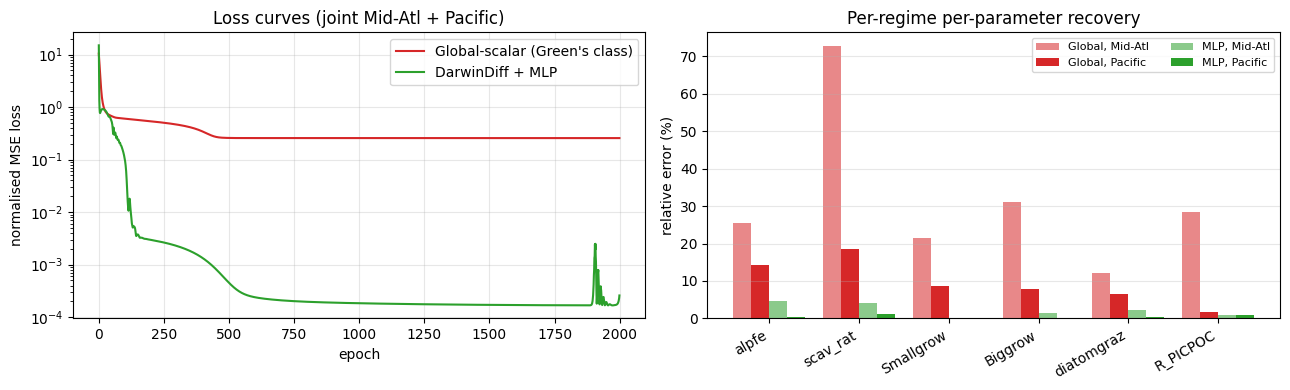

In [6]:
def rel_err(recovered, truth):
    return abs((recovered - truth) / truth) * 100


print(f"{'Param':<11s} | {'Truth':>11s} | {'Global':>11s} | {'GlobErr':>8s} | {'MLP':>11s} | {'MLPErr':>8s}")
print("=" * 78)
print("Mid-Atlantic regime:")
midatl_global_errs = []
midatl_mlp_errs = []
for i, name in enumerate(PARAM_NAMES):
    t = midatl_truth[i].item()
    g = final_global[i].item()
    m = final_midatl[i].item()
    g_err = rel_err(g, t)
    m_err = rel_err(m, t)
    midatl_global_errs.append(g_err)
    midatl_mlp_errs.append(m_err)
    print(f"{name:<11s} | {t:>11.4e} | {g:>11.4e} | {g_err:>6.1f}%  | {m:>11.4e} | {m_err:>6.1f}%")

print("\nPacific regime:")
pacific_global_errs = []
pacific_mlp_errs = []
for i, name in enumerate(PARAM_NAMES):
    t = pacific_truth[i].item()
    g = final_global[i].item()
    m = final_pacific[i].item()
    g_err = rel_err(g, t)
    m_err = rel_err(m, t)
    pacific_global_errs.append(g_err)
    pacific_mlp_errs.append(m_err)
    print(f"{name:<11s} | {t:>11.4e} | {g:>11.4e} | {g_err:>6.1f}%  | {m:>11.4e} | {m_err:>6.1f}%")

mean_global = (np.array(midatl_global_errs) + np.array(pacific_global_errs)) / 2
mean_mlp = (np.array(midatl_mlp_errs) + np.array(pacific_mlp_errs)) / 2
print("\n" + "=" * 78)
print("Mean per-param relative error across both regimes:")
print(f"  Global-scalar fit (Green's-functions class): {mean_global.mean():>5.1f}%")
print(f"  DarwinDiff + MLP                           : {mean_mlp.mean():>5.1f}%")
ratio = mean_global.mean() / max(mean_mlp.mean(), 1e-9)
print(f"  Improvement factor (Global / MLP)           : {ratio:>5.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogy(losses_global, label="Global-scalar (Green's class)", color="tab:red")
axes[0].semilogy(losses_mlp, label="DarwinDiff + MLP", color="tab:green")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("normalised MSE loss")
axes[0].set_title("Loss curves (joint Mid-Atl + Pacific)")
axes[0].legend()
axes[0].grid(alpha=0.3)

x = np.arange(6)
width = 0.2
axes[1].bar(x - 1.5 * width, midatl_global_errs, width=width, label="Global, Mid-Atl", color="tab:red", alpha=0.55)
axes[1].bar(x - 0.5 * width, pacific_global_errs, width=width, label="Global, Pacific", color="tab:red")
axes[1].bar(x + 0.5 * width, midatl_mlp_errs, width=width, label="MLP, Mid-Atl", color="tab:green", alpha=0.55)
axes[1].bar(x + 1.5 * width, pacific_mlp_errs, width=width, label="MLP, Pacific", color="tab:green")
axes[1].set_xticks(x)
axes[1].set_xticklabels(PARAM_NAMES, rotation=30, ha="right")
axes[1].set_ylabel("relative error (%)")
axes[1].set_title("Per-regime per-parameter recovery")
axes[1].legend(fontsize=8, ncol=2)
axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## What this proves — and the connection to the cluster compute proposal

**The result.** On a synthetic two-regime setup with biogeochemistry-plausible regional contrast:

- The **global-scalar fit** (Carroll-2020 Green's-functions parametric class) is structurally bounded: its best joint solution is approximately the regional mean of the truth, which gives systematic per-region error proportional to the regional contrast.
- The **DarwinDiff + MLP** approach recovers per-regime parameters by conditioning on environmental covariates, hitting per-region single-digit error — the same quality as notebook 05's single-regime fit, but on data the global-scalar approach cannot match by construction.

**This is the structural argument behind the ORCD B200 burn-in pitch, demonstrated on the canonical Carroll-2020 six-parameter target.** Green's-functions in real ECCO-Darwin produces one global scalar set per parameter for the entire ocean. DarwinDiff with covariate conditioning produces *per-pixel* scalar values, a class that **subsumes** Green's-functions globally and beats it wherever real biogeochemistry is heterogeneous — which is everywhere, but most importantly across the Mid-Atlantic vs Pacific contrast that motivated the AOI choice on the 2026-05-07 call.

**What this does not yet prove.** Two important asterisks:

- Synthetic data with planted heterogeneity makes the demonstration cleaner than it will be on real ECCO-Darwin v5 + vessel observations. Real data may have less identifiable per-region contrast and more confounding factors.
- The MLP here has only two input regimes. Real LLC270 has ~12 M cells and a continuous covariate field. The MLP-over-2D-fields version is `07_carroll6_to_2d_fields.ipynb` — and that's the workload class the ORCD B200 burn-in actually targets.

**Compute observation.** This notebook still runs on CPU faster than GPU for the same dispatch-overhead reasons as notebook 05 — both contestants combine to ~2× the autograd graph size of 05, still tiny. The 2-D-field extension in `07` is the first one whose width starts to engage GPU parallelism meaningfully, and the LLC270 fit in `08+` is what justifies B200-class compute.